# Calculations of cooling tower with Poppe  and Merkel method.Comparision

## Import of libraries

In [1]:
from lib import AirFlow, WaterFlow, PoppeSolver, u, Q_, MerkelSolver
import matplotlib.pyplot as plt

### Play with units
In this project we use PINT behind - library for units. It makes work with units more or less natural. We provide 2 methods - u and Q_

In [2]:
weight = 1*u.kg
double_weight = 2 * weight
even_heavier = double_weight + 500*u.g
print(f"weight = {weight} double it = {double_weight} add gramms = {even_heavier}")

weight = 1 kilogram double it = 2 kilogram add gramms = 2.5 kilogram


In [3]:
#Distance from town A to town B - 500 km, Time = 12h30min what is average velocity. Different types of initialization
distance = Q_(500, u.km)
travel_time = 12*u.hour + Q_(30, u.minute)
velocity = distance / travel_time
print(f"velocity={velocity:.3f}")

velocity=40.000 kilometer / hour


### Work with temperatures
it is different, you can not multiply or add temperatures
Thats why only one way of initialization -> Q_

In [4]:
#work with temperatures
temp = Q_(30, u.degC)
#Convert to Fahrenheit
print(temp.to(u.degF))
temp_cold = Q_(20, u.degC)
#difference
print(temp - temp_cold)

85.99999999999993 degree_Fahrenheit
10 delta_degree_Celsius


In [5]:
try:
    t = temp + temp_cold
except Exception as e:
    print(e)
    print("You can not add temperatures, use delta_degC")

t = temp + Q_(40.0, u.delta_degC)
print(t)
delta_t = Q_(20.0, u.delta_degC) + Q_(30.0, u.delta_degC) + 2.0*u.delta_degF
print(f"You can do math with delta_deg; delta_t = {delta_t}")

Ambiguous operation with offset unit (degree_Celsius, degree_Celsius). See https://pint.readthedocs.io/en/stable/user/nonmult.html for guidance.
You can not add temperatures, use delta_degC
70.0 degree_Celsius
You can do math with delta_deg; delta_t = 51.111111111111114 delta_degree_Celsius


### Density - units like $kg/m^3$

In [6]:
density = 60*u.tonne/(50*u.m**3)
print(density.to(u.pound/u.gallon))

10.014485342423194 pound / gallon


## External formulas

In [7]:
def evaporation_snip(water_in, water_out, air):
    return (0.0009971 + 0.00002357 * (air.temp) - 0.0000002143 * (air.temp)) * (water_in.temp - water_out.temp)

def evaporation_kurita(water_in, water_out, air):
    retutn (0.575 + 0.011 * air.temp) * (water_in.temp - water_out.temp) / 580

I use PINT python library behind the scene so it is possible to use different units

## Input data

In [8]:
#Air 20C, 60% humidity; 1 atm
#Hot water 45C, 1500 ppm TDS
LG_RATIO = 1.2
air = AirFlow(temp=Q_(20, u.degC), humidity=Q_(60, u.perc))
water_in = WaterFlow(temp=Q_(35, u.degC), salinity=Q_(1500, u.mg/u.kg))
water_out = WaterFlow(temp=Q_(25, u.degC), salinity=Q_(1500, u.mg/u.kg))
# Solver object to calculate everything
psolver = PoppeSolver(air, water_in, water_out, lg_ratio=LG_RATIO)
msolver = MerkelSolver(air, water_in, water_out, lg_ratio=LG_RATIO)

## Results

### Merkel number

In [9]:
me_m = msolver.solve()
me_p = psolver.solve()
print(f"NTU by Merkel = {me_m:.3f}, by Poppe = {me_p:.3f}")

25.0 [4.22898601e+04 8.73448115e-03]
25.063643054773525 [4.26091662e+04 8.84266140e-03]
25.0 [4.22898607e+04 8.73448115e-03]
25.0 [4.22898601e+04 8.73448128e-03]
25.0078882117179 [4.22898601e+04 8.73448115e-03]
25.032811740732903 [4.22898601e+04 8.73448115e-03]
25.050874940563503 [4.22898601e+04 8.73448115e-03]
25.0078882117179 [4.23294363e+04 8.74788871e-03]
25.032811740732903 [4.24544812e+04 8.79024069e-03]
25.050874940563503 [4.25451070e+04 8.82092524e-03]
25.050874940563503 [4.2545107e+04 8.8209251e-03]
25.128400453424344 [4.29340644e+04 8.95252567e-03]
25.37334942770266 [4.41630173e+04 9.36734219e-03]
25.550874940563503 [4.50537004e+04 9.66706210e-03]
25.128400453424344 [4.29340644e+04 8.95252569e-03]
25.37334942770266 [4.41630173e+04 9.36734233e-03]
25.550874940563503 [4.50537004e+04 9.66706290e-03]
25.550874940563503 [4.50537004e+04 9.66706290e-03]
25.628400453424344 [4.54426639e+04 9.79771547e-03]
25.87334942770266 [4.66716359e+04 1.02096062e-02]
26.050874940563503 [4.75623329e

### Calc lg

In [10]:
lg_merkel = msolver.find_operating_lg()
lg_poppe = psolver.find_operating_lg()
print(f"LG calculated by Merkel {lg_merkel} by Poppe {lg_poppe}")

25.0 [4.22898601e+04 8.73448115e-03]
25.063643054773525 [4.26091662e+04 8.84266140e-03]
25.0 [4.22898607e+04 8.73448115e-03]
25.0 [4.22898601e+04 8.73448128e-03]
25.0078882117179 [4.22898601e+04 8.73448115e-03]
25.032811740732903 [4.22898601e+04 8.73448115e-03]
25.050874940563503 [4.22898601e+04 8.73448115e-03]
25.0078882117179 [4.23294363e+04 8.74788871e-03]
25.032811740732903 [4.24544812e+04 8.79024069e-03]
25.050874940563503 [4.25451070e+04 8.82092524e-03]
25.050874940563503 [4.2545107e+04 8.8209251e-03]
25.128400453424344 [4.29340644e+04 8.95252567e-03]
25.37334942770266 [4.41630173e+04 9.36734219e-03]
25.550874940563503 [4.50537004e+04 9.66706210e-03]
25.128400453424344 [4.29340644e+04 8.95252569e-03]
25.37334942770266 [4.41630173e+04 9.36734233e-03]
25.550874940563503 [4.50537004e+04 9.66706290e-03]
25.550874940563503 [4.50537004e+04 9.66706290e-03]
25.628400453424344 [4.54426639e+04 9.79771547e-03]
25.87334942770266 [4.66716359e+04 1.02096062e-02]
26.050874940563503 [4.75623329e

### Estimate_temperatures with given delta t

In [11]:
print(f"MERKEL = {msolver.estimate_temperatures()}")

17.143698899579675
80.0
17.143698899579675
80.0
79.99980132972053
48.5717501146501
32.85772450711489
25.00071170334728
28.76724367114513
27.750194153368213
27.40294106322163
27.41494105364856
27.414541323693552
27.41449132369354
MERKEL = (37.414541323693555, 27.414541323693552, None)


In [12]:
psolver.air_in.wet_bulb_temperature()

15.143698899579675

In [13]:
print(f"MERKEL = {psolver.estimate_temperatures(lg_ratio=1.256)}")

17.143698899579675
17.143698899579675 [4.22898601e+04 8.73448115e-03]
17.18477719370675 [4.25055207e+04 8.85548041e-03]
17.143698899579675 [4.22898607e+04 8.73448115e-03]
17.143698899579675 [4.22898601e+04 8.73448128e-03]
17.150769298278032 [4.22898601e+04 8.73448115e-03]
17.173108871987274 [4.22898601e+04 8.73448115e-03]
17.18929936346212 [4.22898601e+04 8.73448115e-03]
17.150769298278032 [4.23269796e+04 8.75529225e-03]
17.173108871987274 [4.24442622e+04 8.82084931e-03]
17.18929936346212 [4.25292622e+04 8.86817893e-03]
17.18929936346212 [4.25292622e+04 8.86816073e-03]
17.260003350445693 [4.29004584e+04 9.07288982e-03]
17.483399087538096 [4.40732922e+04 9.69917427e-03]
17.645304002286558 [4.49233026e+04 1.01331997e-02]
17.260003350445693 [4.29004584e+04 9.07289296e-03]
17.483399087538096 [4.40732922e+04 9.69919414e-03]
17.645304002286558 [4.49233026e+04 1.01333204e-02]
17.645304002286558 [4.49233026e+04 1.01333187e-02]
17.7228295151474 [4.53303176e+04 1.03352282e-02]
17.967778489425715

ValueError: Poppe solver failed: Dry bulb temperature must be in range [-100, 200]°C

### Profiles

Temperature profile (air temperature accross the tower)

Text(0, 0.5, 'Air temperature')

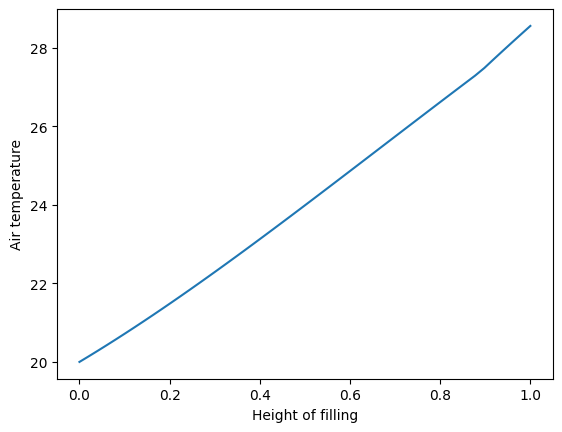

In [4]:
x = (solver.profiles["water_temp_c"] - solver.profiles["water_temp_c"].min())/(solver.profiles["water_temp_c"].max() - solver.profiles["water_temp_c"].min())
y = solver.profiles["air_temp_c"]
plt.plot(x, y)
plt.xlabel("Height of filling")
plt.ylabel("Air temperature")

Humidity of air

Text(0, 0.5, 'Air humidity')

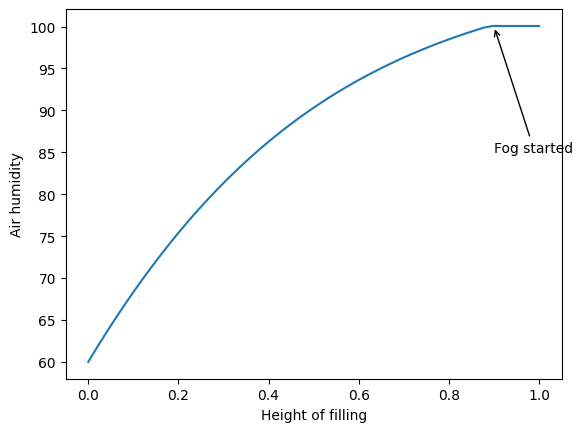

In [5]:
y = solver.profiles["air_rh_perc"]
plt.plot(x, y)
plt.xlabel("Height of filling")
plt.annotate(
    "Fog started",
    xy=(0.9, 100),
    xycoords="data",
    xytext=(0.9, 85),
    textcoords="data",
    arrowprops=dict(arrowstyle="->")
)
plt.ylabel("Air humidity")

In [7]:
width = 70
print(f"{'Evaporation (real evaporation + fog drift):':<{width}} {solver.evaporation*100:>8.2f}%")
print(f"{'Merkel Number:':<{width}} {me:>8.2f}")
print(f"{'Fog drift:':<{width}} {solver.fog_force*100:>8.2f}%")
print(f"{'Relative parameter to understand which part of filling in a fog area:':<{width}} {solver.fog_force:>8.2f}%")
print(f"{'Approach:':<{width}} {solver.water_in.temp - solver.air_in.wet_bulb_temperature():>8.2f}")

Evaporation (real evaporation + fog drift):                                1.35%
Merkel Number:                                                             1.26
Fog drift:                                                              1200.00%
Relative parameter to understand which part of filling in a fog area:     12.00%
Approach:                                                                 19.86


### According to Merkel theory $Me = C * (LG)^{-n}$, C and n are characteristics of cooling tower and comes from manufacturer. Let's assume n = 0.6. C is a parameter which can be used as a KPI of efficacy of cooling tower. 

In [9]:
C = me/LG_RATIO**(-0.6)
print(f"C = {C:.2f}")

C = 1.40


## Predicting of temperatures
Now we have C and n, our inlet temperature is 35C and outlet is 25C. Delta t = 10C defined by process (let say we have a condenser with stable heat load). What will happen weather becomes hotter?
Let assume that Air temperature is 40C and humidity is 40% and our requirements to cold water are 30C. We can use calculated merkel number because we will keep LG ratio the same

In [11]:
air = AirFlow(temp=Q_(40, u.degC), humidity=Q_(40, u.perc))
target_merkel = me
delta_t = Q_(10, u.delta_degC)
lg_ratio = 1.2
water_salinity = Q_(1000, u.mg/u.kg)

In [17]:
with solver.temporary_set():
    solver.lg_ratio = 1.2
    t_in, t_out, _ = solver.estimate_temperatures(delta_t=delta_t, target_me=target_merkel)

Approach was 9.9 C and become 4.7. But efficacy of cooling tower is the same

In [18]:
solver.estimate_temperatures()

(37.41399903666102, 27.413999036661018, None)